## 각 데이터셋별로 train, validation, test 데이터셋 분리 (user_id 기준)

In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

def tr_val_test_split(df):
    # 1개 이하만 존재하는 클래스는 train set에 포함
    class_counts = df['label'].value_counts()
    valid_classes = class_counts[class_counts >= 2].index
    stratify_df = df[df['label'].isin(valid_classes)]

    rare_df = df[~df['label'].isin(valid_classes)]

    train_df, tmp_df = train_test_split(stratify_df, test_size=0.2, random_state=42, stratify=stratify_df['label'])
    train_df = pd.concat([train_df, rare_df], ignore_index=True)

    try:
        val_df, test_df = train_test_split(tmp_df, test_size=0.5, stratify=tmp_df['label'], random_state=42)
    except ValueError as e:
        tmp_class_counts = tmp_df['label'].value_counts()
        tmp_valid_classes = tmp_class_counts[tmp_class_counts >= 2].index
        tmp_stratify_df = tmp_df[tmp_df['label'].isin(tmp_valid_classes)]

        tmp_rare_df = tmp_df[~tmp_df['label'].isin(tmp_valid_classes)]

        val_df, test_df = train_test_split(tmp_stratify_df, test_size=0.2, random_state=42, stratify=tmp_stratify_df['label'])
        val_df = pd.concat([val_df, tmp_rare_df], ignore_index=True)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    counts = [train_df['label'].value_counts().sort_index(), val_df.value_counts('label').sort_index(), test_df.value_counts('label').sort_index()]
    
    for i, ax in enumerate(axes):
        counts[i].plot(kind='bar', ax=ax)
        ax.set_title(['Train', 'Validation', 'Test'][i])
        ax.set_xlabel('label')
        ax.set_ylabel('count')
    plt.tight_layout()
    
    plt.show()

    return train_df, val_df, test_df

### 028_data

In [2]:
import os
import json
import pandas as pd

label_dir = '/home/work/hocheol_dir/datasets/v0.2_data/pigment/028_data/label'

origin_df = pd.read_json(os.path.join(label_dir, 'pig_label.json'), orient='records', dtype={'user_id':str, })
origin_df['label'] = origin_df.apply(lambda x:x['left_label'] if pd.notna(x['left_label']) else x['right_label'], axis=1)

user_split = origin_df.loc[:, ['user_id', 'label']].drop_duplicates(ignore_index=True)
user_split

,user_id,label
0,0001,2
1,0002,2
2,0003,0
3,0004,2
4,0006,2
...,...,...
960,1096,1
961,1097,0
962,1098,0
963,1099,0


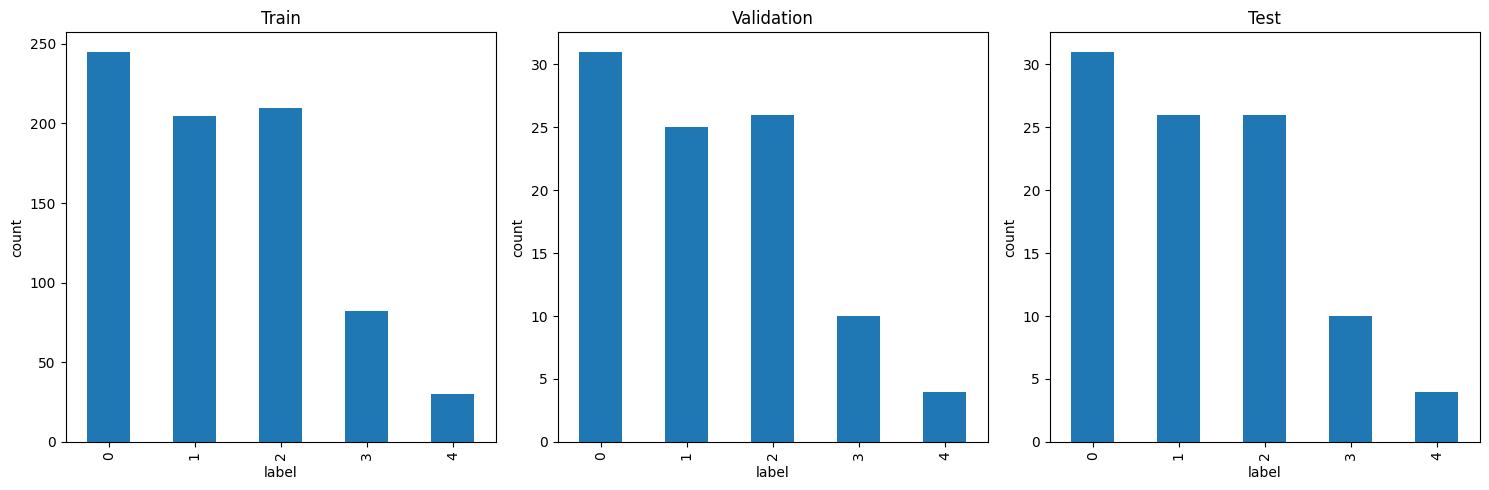

In [3]:
train_df, val_df, test_df = tr_val_test_split(user_split)

In [4]:
len(train_df)

772

In [5]:
split_train = pd.merge(train_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'left_path'])
split_val = pd.merge(val_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'left_path'])
split_test = pd.merge(test_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'left_path'])

In [6]:
split_train.drop(columns=['label_x', 'label_y'], inplace=True)
split_val.drop(columns=['label_x', 'label_y'], inplace=True)
split_test.drop(columns=['label_x', 'label_y'], inplace=True)

In [7]:
split_train

,user_id,equipment,left_path,right_path,left_label,right_label
2145,0001,1,028_data/data/left_0001_01_F.jpg,028_data/data/right_0001_01_F.jpg,2,2
2146,0001,1,028_data/data/left_0001_01_L15.jpg,028_data/data/right_0001_01_R15.jpg,2,2
2147,0001,1,028_data/data/left_0001_01_L30.jpg,028_data/data/right_0001_01_R30.jpg,2,2
2148,0001,2,028_data/data/left_0001_02_F.jpg,028_data/data/right_0001_02_F.jpg,2,2
2149,0001,2,028_data/data/left_0001_02_L.jpg,028_data/data/right_0001_02_R.jpg,2,2
...,...,...,...,...,...,...
1215,1100,1,028_data/data/left_1100_01_F.jpg,028_data/data/right_1100_01_F.jpg,1,1
1216,1100,1,028_data/data/left_1100_01_L15.jpg,028_data/data/right_1100_01_R15.jpg,1,1
1217,1100,1,028_data/data/left_1100_01_L30.jpg,028_data/data/right_1100_01_R30.jpg,1,1
1218,1100,2,028_data/data/left_1100_02_F.jpg,028_data/data/right_1100_02_F.jpg,1,1


In [8]:
# user_id로 교집합을 구하여 중복된 user_id의 수를 확인

len(pd.merge(split_train, split_val, on='user_id', how='inner')), \
len(pd.merge(split_train, split_test, on='user_id', how='inner')), \
len(pd.merge(split_val, split_test, on='user_id', how='inner'))

(0, 0, 0)

In [9]:
with open(os.path.join(label_dir, 'pig_train.json'), 'w') as f:
    json.dump(split_train.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'pig_val.json'), 'w') as f:
    json.dump(split_val.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'pig_test.json'), 'w') as f:
    json.dump(split_test.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

### 030_data

In [48]:
import os
import json
import pandas as pd

label_dir = '/home/work/hocheol_dir/datasets/v0.2_data/pigment/030_data/label'

origin_df = pd.read_json(os.path.join(label_dir, 'pig_label.json'), orient='records', dtype={'user_id':str, })
origin_df['label'] = origin_df.apply(lambda x:x['left_label'] if pd.notna(x['left_label']) else x['right_label'], axis=1)

user_split = origin_df.loc[:, ['user_id', 'label']].drop_duplicates(ignore_index=True)
user_split

,user_id,label
0,0001,0
1,0002,1
2,0005,1
3,0003,0
4,0007,0
...,...,...
1619,1977,3
1620,1976,1
1621,1978,2
1622,1979,4


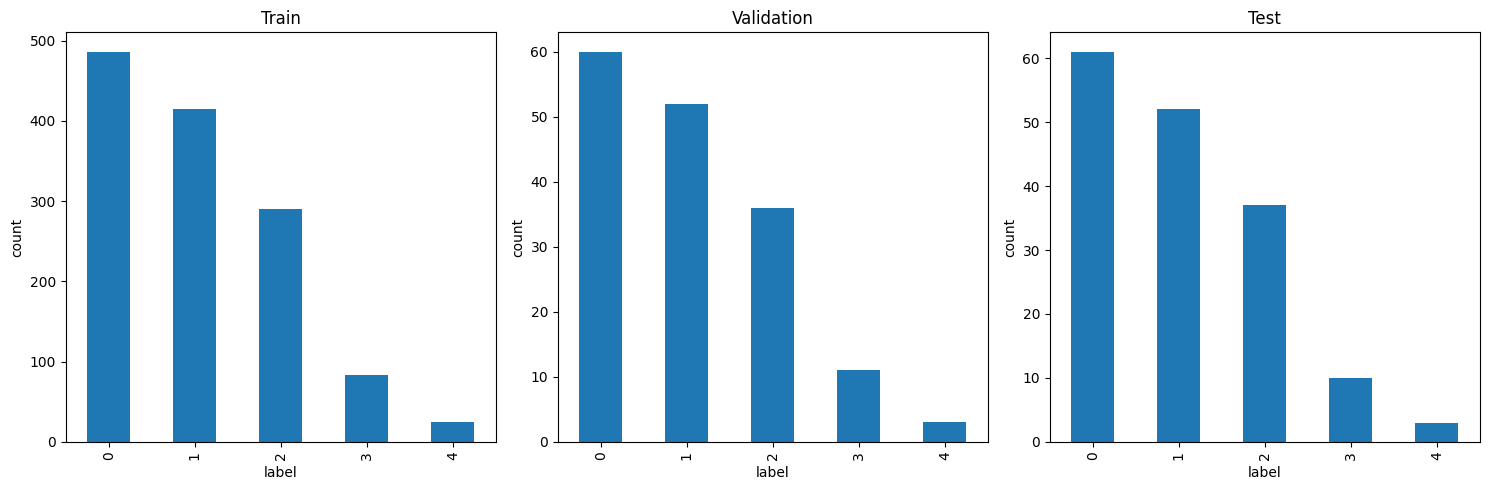

In [49]:
train_df, val_df, test_df = tr_val_test_split(user_split)

In [34]:
len(train_df)

1299

In [35]:
split_train = pd.merge(train_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'left_path'])
split_val = pd.merge(val_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'left_path'])
split_test = pd.merge(test_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'left_path'])

In [36]:
split_train.drop(columns=['label_x', 'label_y'], inplace=True)
split_val.drop(columns=['label_x', 'label_y'], inplace=True)
split_test.drop(columns=['label_x', 'label_y'], inplace=True)

In [37]:
split_train

,user_id,left_path,right_path,left_label,right_label
915,0001,030_data/data/left_0001_face.jpg,030_data/data/right_0001_face.jpg,0,0
301,0004,030_data/data/left_0004_face.jpg,030_data/data/right_0004_face.jpg,0,0
171,0005,030_data/data/left_0005_face.jpg,030_data/data/right_0005_face.jpg,1,1
1149,0006,030_data/data/left_0006_face.jpg,030_data/data/right_0006_face.jpg,0,0
1193,0007,030_data/data/left_0007_face.JPG,030_data/data/right_0007_face.JPG,0,0
...,...,...,...,...,...
1270,1976,030_data/data/left_1976_face.jpg,030_data/data/right_1976_face.jpg,1,2
303,1977,030_data/data/left_1977_face.jpg,030_data/data/right_1977_face.jpg,3,2
708,1978,030_data/data/left_1978_face.jpg,030_data/data/right_1978_face.jpg,2,1
1280,1979,030_data/data/left_1979_face.jpg,030_data/data/right_1979_face.jpg,4,4


In [38]:
# user_id로 교집합을 구하여 중복된 user_id의 수를 확인

len(pd.merge(split_train, split_val, on='user_id', how='inner')), \
len(pd.merge(split_train, split_test, on='user_id', how='inner')), \
len(pd.merge(split_val, split_test, on='user_id', how='inner'))

(0, 0, 0)

In [39]:
with open(os.path.join(label_dir, 'pig_train.json'), 'w') as f:
    json.dump(split_train.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'pig_val.json'), 'w') as f:
    json.dump(split_val.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'pig_test.json'), 'w') as f:
    json.dump(split_test.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

### 034_data

In [92]:
import os
import json
import pandas as pd

label_dir = '/home/work/hocheol_dir/datasets/v0.2_data/pigment/034_data/label'

origin_df = pd.read_json(os.path.join(label_dir, 'pig_label.json'), orient='records', dtype={'user_id':str, })
origin_df['label'] = origin_df.apply(lambda x:x['left_label'] if pd.notna(x['left_label']) else x['right_label'], axis=1)

filtered_df = origin_df[origin_df['label'] != 6]

# 하나의 user_id에 대해 여러 개의 label이 존재하는 경우, 하나만 선택(유일한 user_id를 유지)
# user_split = origin_df.loc[:, ['user_id', 'label']].drop_duplicates(ignore_index=True)
user_split = filtered_df.groupby('user_id')['label'].agg(lambda x:x.mode().iloc[0]).reset_index()
user_split

,user_id,label
0,0000,0
1,0001,1
2,0002,0
3,0003,2
4,0004,3
...,...,...
2670,2695,0
2671,2696,1
2672,2697,0
2673,2698,1


In [93]:
user_split['label'].value_counts().sort_index()

label
0    907
1    697
2    652
3    305
4    114
Name: count, dtype: int64

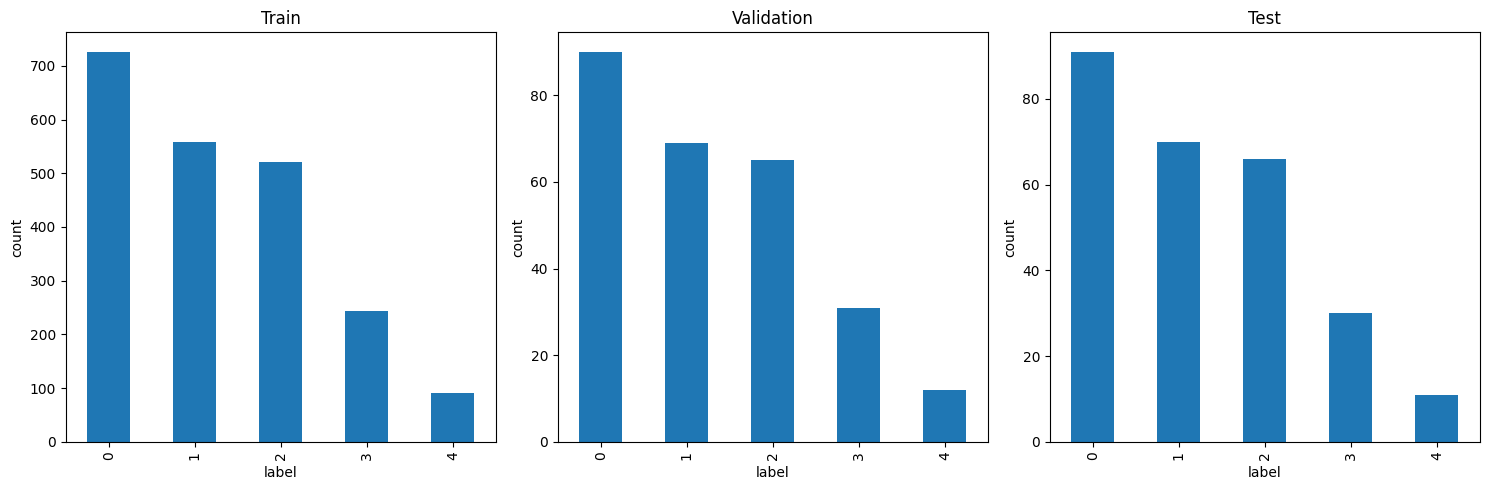

In [94]:
train_df, val_df, test_df = tr_val_test_split(user_split)

In [95]:
# train, val, test의 개수 합이 origin과 같으면 한 사람이 여러장 찍지 않았음
len(origin_df), len(train_df), len(val_df), len(test_df)

(5400, 2140, 267, 268)

In [96]:
split_train = pd.merge(train_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'left_path'])
split_val = pd.merge(val_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'left_path'])
split_test = pd.merge(test_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'left_path'])

split_train.drop(columns=['label_x', 'label_y'], inplace=True)
split_val.drop(columns=['label_x', 'label_y'], inplace=True)
split_test.drop(columns=['label_x', 'label_y'], inplace=True)

# user_id로 교집합을 구하여 중복된 user_id의 수를 확인
len(pd.merge(split_train, split_val, on='user_id', how='inner')), \
len(pd.merge(split_train, split_test, on='user_id', how='inner')), \
len(pd.merge(split_val, split_test, on='user_id', how='inner'))

(0, 0, 0)

In [99]:
with open(os.path.join(label_dir, 'pig_train.json'), 'w') as f:
    json.dump(split_train.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'pig_val.json'), 'w') as f:
    json.dump(split_val.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'pig_test.json'), 'w') as f:
    json.dump(split_test.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

### 045_data

In [110]:
import os
import json
import pandas as pd

label_dir = '/home/work/hocheol_dir/datasets/v0.2_data/pigment/045_data/label'

origin_df = pd.read_json(os.path.join(label_dir, 'pig_label.json'), orient='records', dtype={'user_id':str, })
origin_df['label'] = origin_df.apply(lambda x:x['left_label'] if pd.notna(x['left_label']) else x['right_label'], axis=1)

filtered_df = origin_df[origin_df['label'] != 6]

# 하나의 user_id에 대해 여러 개의 label이 존재하는 경우, 하나만 선택(유일한 user_id를 유지)
# user_split = origin_df.loc[:, ['user_id', 'label']].drop_duplicates(ignore_index=True)
user_split = filtered_df.groupby('user_id')['label'].agg(lambda x:x.mode().iloc[0]).reset_index()
user_split

,user_id,label
0,F0001_IND_D,0.0
1,F0001_IND_GM,4.0
2,F0001_IND_M,1.0
3,F0002_IND_S,0.0
4,F0003_IND_D,0.0
...,...,...
796,F0897_IND_M,2.0
797,F0898_IND_D,0.0
798,F0898_IND_D2,0.0
799,F0898_IND_F,1.0


In [111]:
user_split['label'].value_counts().sort_index()

label
0.0    326
1.0    209
2.0    186
3.0     62
4.0     18
Name: count, dtype: int64

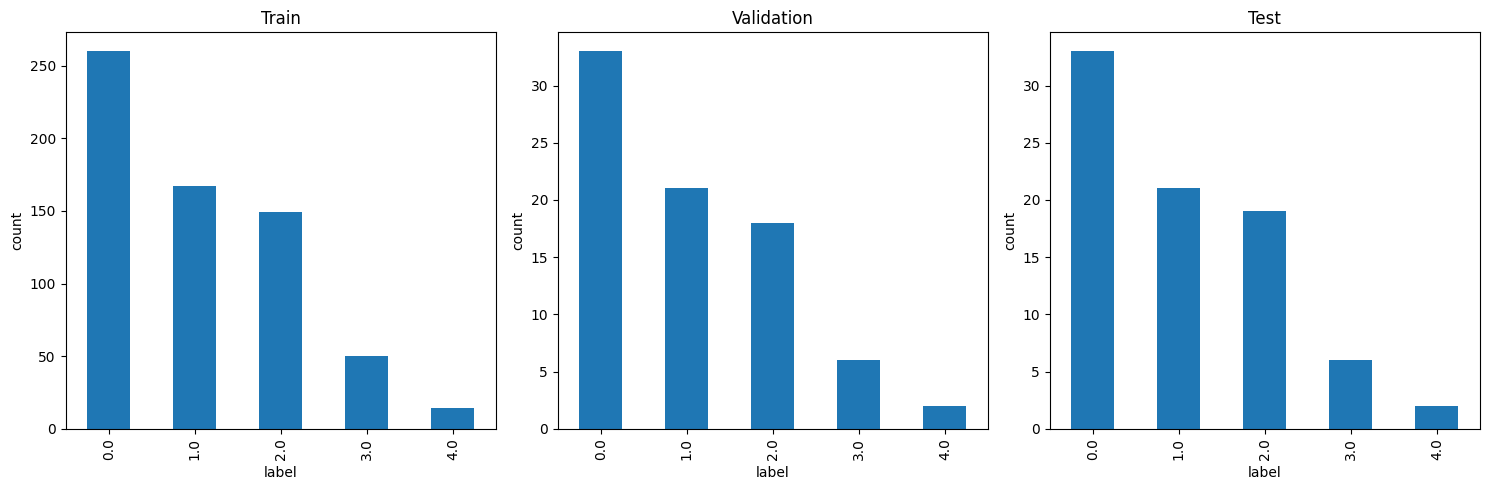

In [112]:
train_df, val_df, test_df = tr_val_test_split(user_split)

In [113]:
# train, val, test의 개수 합이 origin과 같으면 한 사람이 여러장 찍지 않았음
len(origin_df), len(train_df), len(val_df), len(test_df)

(3356, 640, 80, 81)

In [114]:
split_train = pd.merge(train_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'left_path'])
split_val = pd.merge(val_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'left_path'])
split_test = pd.merge(test_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'left_path'])

split_train.drop(columns=['label_x', 'label_y'], inplace=True)
split_val.drop(columns=['label_x', 'label_y'], inplace=True)
split_test.drop(columns=['label_x', 'label_y'], inplace=True)

# user_id로 교집합을 구하여 중복된 user_id의 수를 확인
len(pd.merge(split_train, split_val, on='user_id', how='inner')), \
len(pd.merge(split_train, split_test, on='user_id', how='inner')), \
len(pd.merge(split_val, split_test, on='user_id', how='inner'))

(0, 0, 0)

In [115]:
with open(os.path.join(label_dir, 'pig_train.json'), 'w') as f:
    json.dump(split_train.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'pig_val.json'), 'w') as f:
    json.dump(split_val.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'pig_test.json'), 'w') as f:
    json.dump(split_test.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

### 118_data

In [118]:
import os
import json
import pandas as pd

label_dir = '/home/work/hocheol_dir/datasets/v0.2_data/pigment/118_data/label'

origin_df = pd.read_json(os.path.join(label_dir, 'pig_label.json'), orient='records', dtype={'user_id':str, })
origin_df['label'] = origin_df.apply(lambda x:x['left_label'] if pd.notna(x['left_label']) else x['right_label'], axis=1)

filtered_df = origin_df[origin_df['label'] != 6]

# 하나의 user_id에 대해 여러 개의 label이 존재하는 경우, 하나만 선택(유일한 user_id를 유지)
# user_split = origin_df.loc[:, ['user_id', 'label']].drop_duplicates(ignore_index=True)
user_split = filtered_df.groupby('user_id')['label'].agg(lambda x:x.mode().iloc[0]).reset_index()
user_split

,user_id,label
0,0002,0
1,0003,0
2,0010,0
3,0013,0
4,0016,2
...,...,...
280,0989,0
281,0990,0
282,0993,0
283,0994,0


In [119]:
user_split['label'].value_counts().sort_index()

label
0    225
1     43
2     16
3      1
Name: count, dtype: int64

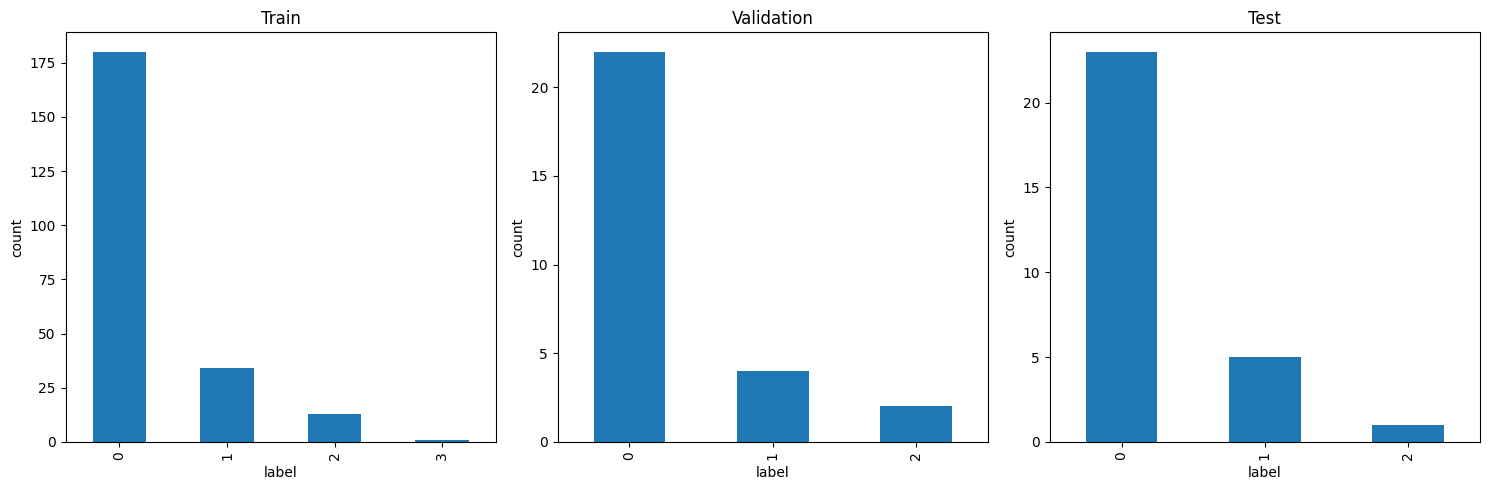

In [120]:
train_df, val_df, test_df = tr_val_test_split(user_split)

In [121]:
# train, val, test의 개수 합이 origin과 같으면 한 사람이 여러장 찍지 않았음
len(origin_df), len(train_df), len(val_df), len(test_df)

(775, 228, 28, 29)

In [122]:
split_train = pd.merge(train_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'left_path'])
split_val = pd.merge(val_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'left_path'])
split_test = pd.merge(test_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'left_path'])

split_train.drop(columns=['label_x', 'label_y'], inplace=True)
split_val.drop(columns=['label_x', 'label_y'], inplace=True)
split_test.drop(columns=['label_x', 'label_y'], inplace=True)

# user_id로 교집합을 구하여 중복된 user_id의 수를 확인
len(pd.merge(split_train, split_val, on='user_id', how='inner')), \
len(pd.merge(split_train, split_test, on='user_id', how='inner')), \
len(pd.merge(split_val, split_test, on='user_id', how='inner'))

(0, 0, 0)

In [123]:
with open(os.path.join(label_dir, 'pig_train.json'), 'w') as f:
    json.dump(split_train.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'pig_val.json'), 'w') as f:
    json.dump(split_val.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'pig_test.json'), 'w') as f:
    json.dump(split_test.to_dict(orient='records'), f, indent=2, ensure_ascii=False)

### 999_data

In [124]:
import os
import json
import pandas as pd

label_dir = '/home/work/hocheol_dir/datasets/v0.2_data/pigment/999_data/label'

origin_df = pd.read_json(os.path.join(label_dir, 'pig_label.json'), orient='records', dtype={'user_id':str, })
origin_df['label'] = origin_df.apply(lambda x:x['left_label'] if pd.notna(x['left_label']) else x['right_label'], axis=1)

filtered_df = origin_df[origin_df['label'] != 6]

# 하나의 user_id에 대해 여러 개의 label이 존재하는 경우, 하나만 선택(유일한 user_id를 유지)
# user_split = origin_df.loc[:, ['user_id', 'label']].drop_duplicates(ignore_index=True)
user_split = filtered_df.groupby('user_id')['label'].agg(lambda x:x.mode().iloc[0]).reset_index()
user_split

,user_id,label
0,6101,0.0
1,6102,0.0
2,6103,0.0
3,6104,0.0
4,6105,0.0
...,...,...
196,6298,2.0
197,6299,0.0
198,6300,1.0
199,6301,0.0


In [125]:
user_split['label'].value_counts().sort_index()

label
0.0    105
1.0     59
2.0     26
3.0      9
4.0      2
Name: count, dtype: int64

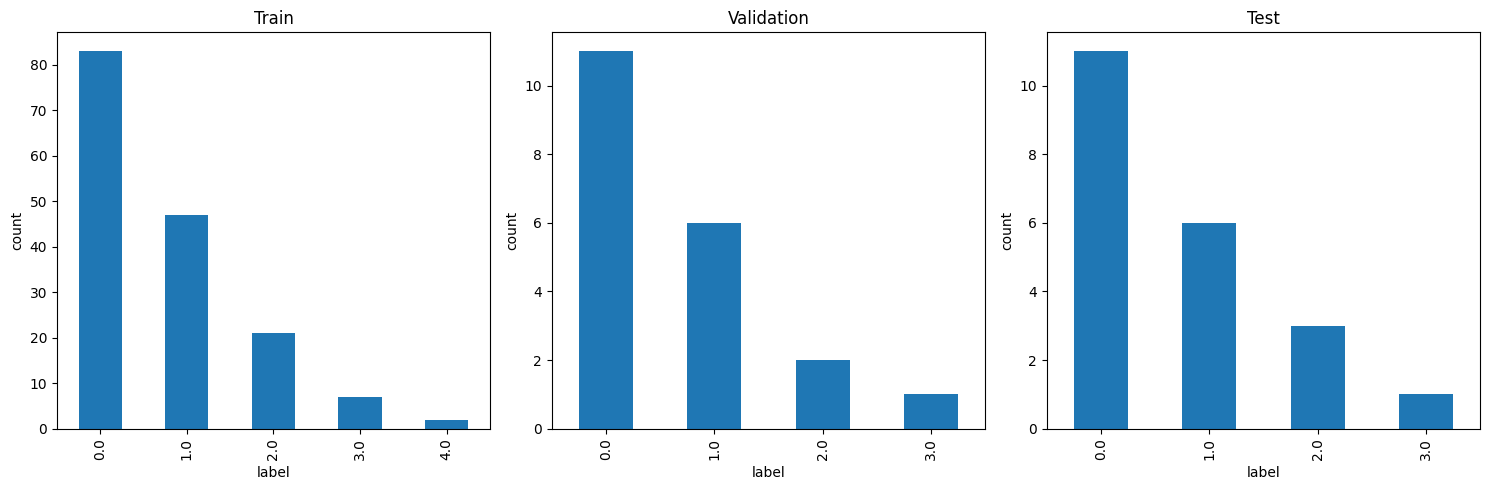

In [126]:
train_df, val_df, test_df = tr_val_test_split(user_split)

In [127]:
# train, val, test의 개수 합이 origin과 같으면 한 사람이 여러장 찍지 않았음
len(origin_df), len(train_df), len(val_df), len(test_df)

(3160, 160, 20, 21)

In [128]:
split_train = pd.merge(train_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'left_path'])
split_val = pd.merge(val_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'left_path'])
split_test = pd.merge(test_df, origin_df, on='user_id', how='left').sort_values(by=['user_id', 'left_path'])

split_train.drop(columns=['label_x', 'label_y'], inplace=True)
split_val.drop(columns=['label_x', 'label_y'], inplace=True)
split_test.drop(columns=['label_x', 'label_y'], inplace=True)

# user_id로 교집합을 구하여 중복된 user_id의 수를 확인
len(pd.merge(split_train, split_val, on='user_id', how='inner')), \
len(pd.merge(split_train, split_test, on='user_id', how='inner')), \
len(pd.merge(split_val, split_test, on='user_id', how='inner'))

(0, 0, 0)

In [129]:
with open(os.path.join(label_dir, 'pig_train.json'), 'w') as f:
    json.dump(split_train.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'pig_val.json'), 'w') as f:
    json.dump(split_val.to_dict(orient='records'), f, indent=2, ensure_ascii=False)
with open(os.path.join(label_dir, 'pig_test.json'), 'w') as f:
    json.dump(split_test.to_dict(orient='records'), f, indent=2, ensure_ascii=False)